In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

In [2]:
_path1 = 'C:\\Users\\86994\\Desktop\\12.jpg'
img = cv2.imread(_path1)
print(img.shape)

(802, 462, 3)


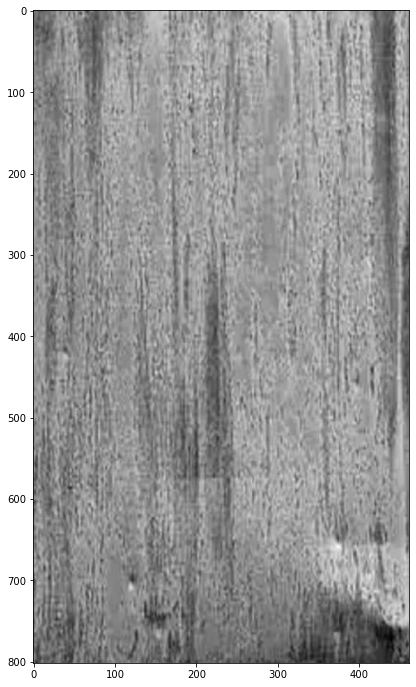

In [3]:
plt.figure(figsize=(9,12))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap='gray')

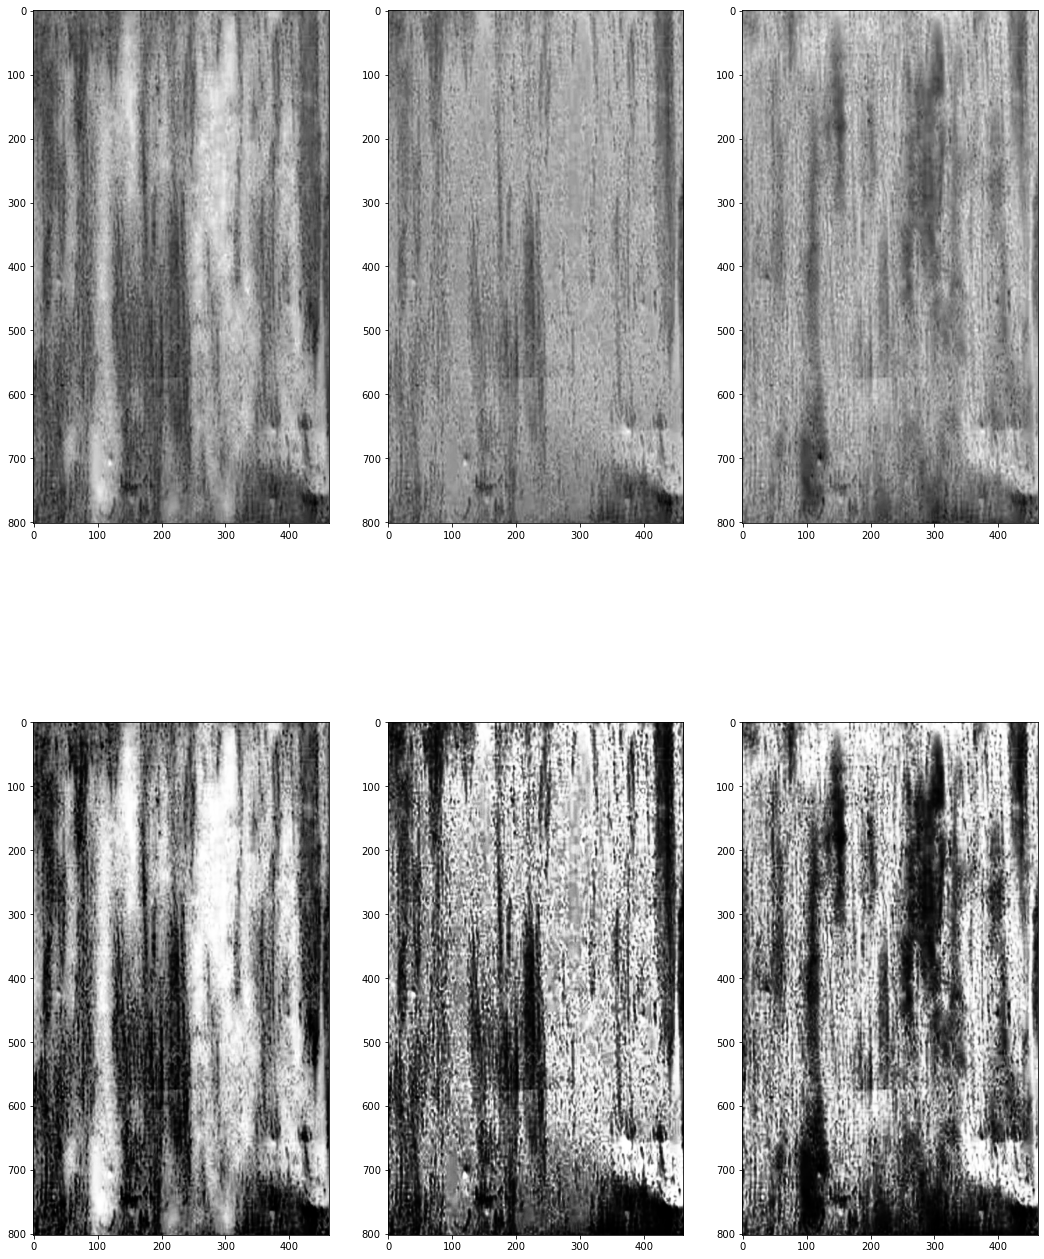

In [4]:
plt.figure(figsize=(18,24))
for i in [1,2,3]: # BGR通道作图
    plt.subplot(2,3,i)
    plt.imshow(img[:,:,i-1], cmap='gray') 
    
for i in [4,5,6]: # BGR通道作图,直方图均衡化之后
    plt.subplot(2,3,i)
    plt.imshow(cv2.equalizeHist(img[:,:,i-4]), cmap='gray') 
plt.show()

In [5]:
data = img / 255.0 # use 0...1 scale
data = data.reshape(-1, 3)

In [6]:
from sklearn.cluster import MiniBatchKMeans
_kmeans = MiniBatchKMeans(2)
_kmeans.fit(data)
new_colors = _kmeans.cluster_centers_[_kmeans.predict(data)]

d:\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:887: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1024 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


In [7]:
img_recolored = new_colors.reshape(img.shape)
img_recolored = (img_recolored*255).astype(np.uint8)

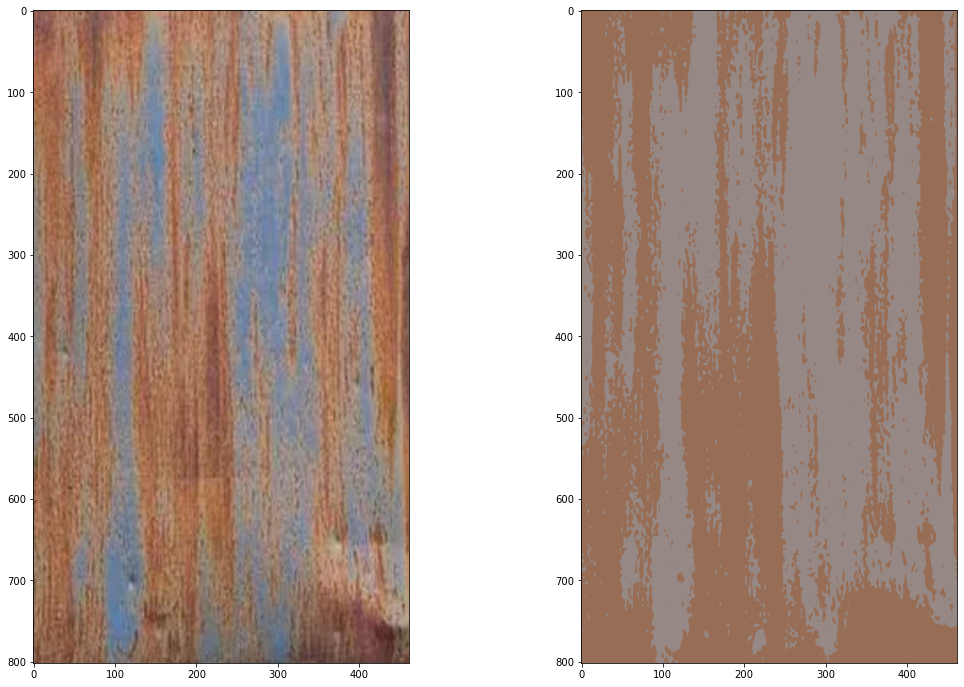

In [8]:
plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_recolored, cv2.COLOR_BGR2RGB))

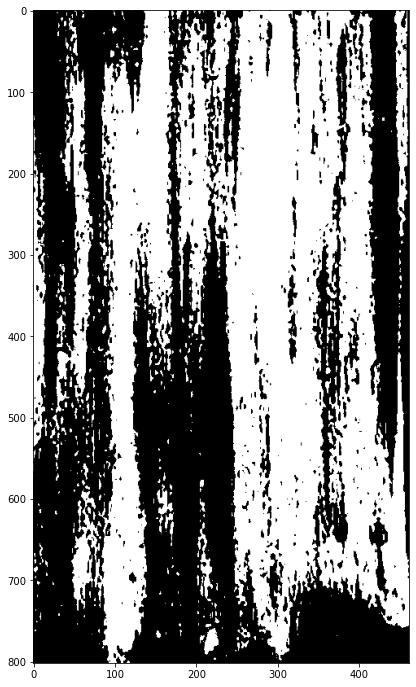

In [9]:
img_recolored_gray = cv2.cvtColor(img_recolored, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(9,12))
plt.imshow(img_recolored_gray, cmap='gray')

In [10]:
min_pixel, max_pixel = np.min(img_recolored_gray), np.max(img_recolored_gray) #分两个颜色

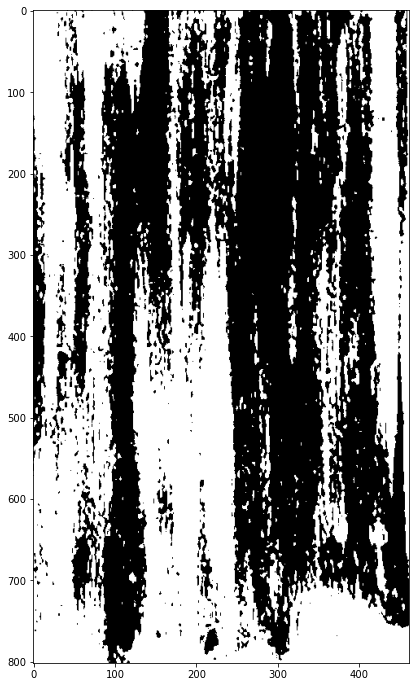

In [11]:
img_recolored_gray_b = np.zeros_like(img_recolored_gray,dtype=np.uint8)*255
img_recolored_gray_b[img_recolored_gray.__eq__(min_pixel)] = 255 # 锈迹处为白色
plt.figure(figsize=(9,12))
plt.imshow(img_recolored_gray_b, cmap='gray')

In [12]:
# 叠加图片查看效果
# add_img = img_recolored_gray_b.astype(np.float32) / 255.
add_img = np.full_like(img, [0,0,0], dtype=np.float32)
add_img[img_recolored_gray_b==255] = np.array([0,252,0])

In [13]:
add_img = add_img/255.0

In [14]:
source_img_flaot = img.astype(np.float32)/255.

In [15]:
result_img = source_img_flaot + add_img * 0.8

In [22]:
# 统计面积
area = np.count_nonzero(img_recolored_gray_b==255)
area_ratio = area/(img_recolored_gray_b.shape[0]*img_recolored_gray_b.shape[1])

In [24]:
import matplotlib
# 预设字体格式，并传给rc方法
font = {'family': 'SimHei', "size": 24}
matplotlib.rc('font', **font)  # 一次定义终身使用

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


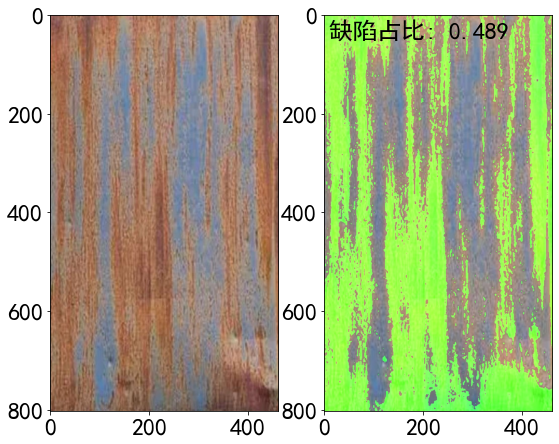

In [26]:
plt.figure(figsize=(9,24))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.text(10, 50, "缺陷占比: {}".format(str(area_ratio)[:5]))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))

In [19]:
print("缺陷占比：{}".format(area_ratio))

缺陷占比：0.4895310425235612
